In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year-Month
df['Year_Month'] = df['Order Date'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = df.groupby('Year_Month')['Sales'].sum().reset_index()
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)

# Convert to datetime index
monthly_sales['Year_Month'] = pd.to_datetime(monthly_sales['Year_Month'])
monthly_sales.set_index('Year_Month', inplace=True)

monthly_sales.head()

,Sales
Year_Month,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


In [3]:
monthly_sales['Lag_1'] = monthly_sales['Sales'].shift(1)
monthly_sales['Lag_2'] = monthly_sales['Sales'].shift(2)
monthly_sales['Lag_3'] = monthly_sales['Sales'].shift(3)

monthly_sales = monthly_sales.dropna()

In [4]:
train = monthly_sales.iloc[:-6]
test = monthly_sales.iloc[-6:]

X_train = train[['Lag_1', 'Lag_2', 'Lag_3']]
y_train = train['Sales']

X_test = test[['Lag_1', 'Lag_2', 'Lag_3']]
y_test = test['Sales']

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))

Linear Regression MAE: 28650.079982892537


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest MAE: 27735.105506833348


In [7]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, xgb_pred))

XGBoost MAE: 31902.76230208333


In [8]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['Sales'], order=(1,1,1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=6)

print("ARIMA MAE:", mean_absolute_error(y_test, arima_pred))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA MAE: 31874.3745470151


In [9]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'ARIMA'],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, arima_pred)
    ]
})

results.sort_values('MAE')

,Model,MAE
1,Random Forest,27735.105507
0,Linear Regression,28650.079983
3,ARIMA,31874.374547
2,XGBoost,31902.762302


**Lower MAE = Better model**

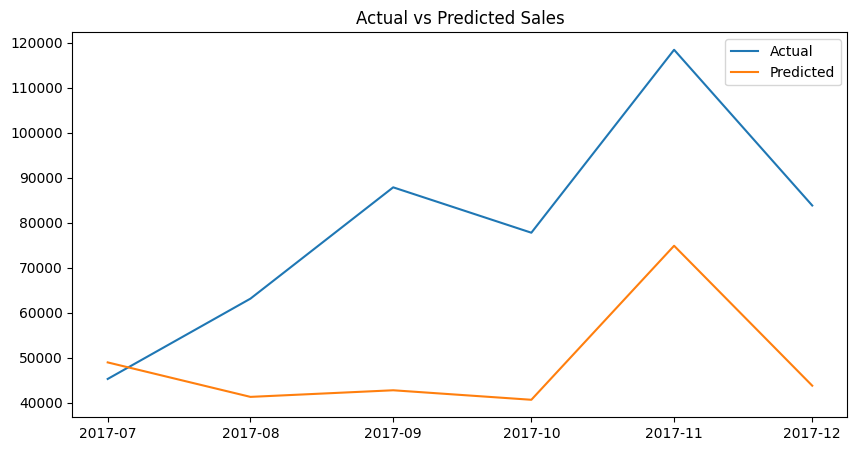

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, xgb_pred, label='Predicted')  # change if needed
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()